<a href="https://colab.research.google.com/github/ranis8912/Purdue_AIML_Course/blob/main/HomeLoan_SaiMandava.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Home Loan Analysis**

1. Load the dataset that is given to you

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading the dataset
src = pd.read_csv("loan_data.csv")
src.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
src.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [ ]:
src.count()

,0
SK_ID_CURR,307511
TARGET,307511
NAME_CONTRACT_TYPE,307511
CODE_GENDER,307511
FLAG_OWN_CAR,307511
...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992
AMT_REQ_CREDIT_BUREAU_WEEK,265992
AMT_REQ_CREDIT_BUREAU_MON,265992
AMT_REQ_CREDIT_BUREAU_QRT,265992


In [ ]:
src.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
src.info

<bound method DataFrame.info of         SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0           100002       1         Cash loans           M            N   
1           100003       0         Cash loans           F            N   
2           100004       0    Revolving loans           M            Y   
3           100006       0         Cash loans           F            N   
4           100007       0         Cash loans           M            N   
...            ...     ...                ...         ...          ...   
307506      456251       0         Cash loans           M            N   
307507      456252       0         Cash loans           F            N   
307508      456253       0         Cash loans           F            N   
307509      456254       1         Cash loans           F            N   
307510      456255       0         Cash loans           F            N   

       FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
0                    Y             0          202500.0    406597.5   
1                    N             0          270000.0   1293502.5   
2                    Y             0           67500.0    135000.0   
3                    Y             0          135000.0    312682.5   
4                    Y             0          121500.0    513000.0   
...                ...           ...               ...         ...   
307506               N             0          157500.0    254700.0   
307507               Y             0           72000.0    269550.0   
307508               Y             0          153000.0    677664.0   
307509               Y             0          171000.0    370107.0   
307510               N             0          157500.0    675000.0   

        AMT_ANNUITY  ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20  \
0           24700.5  ...                 0                0                0   
1           35698.5  ...                 0                0                0   
2            6750.0  ...                 0                0                0   
3           29686.5  ...                 0                0                0   
4           21865.5  ...                 0                0                0   
...             ...  ...               ...              ...              ...   
307506      27558.0  ...                 0                0                0   
307507      12001.5  ...                 0                0                0   
307508      29979.0  ...                 0                0                0   
307509      20205.0  ...                 0                0                0   
307510      49117.5  ...                 0                0                0   

       FLAG_DOCUMENT_21 AMT_REQ_CREDIT_BUREAU_HOUR AMT_REQ_CREDIT_BUREAU_DAY  \
0                     0                        0.0                       0.0   
1                     0                        0.0                       0.0   
2                     0                        0.0                       0.0   
3                     0                        NaN                       NaN   
4                     0                        0.0                       0.0   
...                 ...                        ...                       ...   
307506                0                        NaN                       NaN   
307507                0                        NaN                       NaN   
307508                0                        1.0                       0.0   
307509                0                        0.0                       0.0   
307510                0                        0.0                       0.0   

        AMT_REQ_CREDIT_BUREAU_WEEK  AMT_REQ_CREDIT_BUREAU_MON  \
0                              0.0                        0.0   
1                              0.0                        0.0   
2                              0.0                        0.0   
3                              NaN                      

In [ ]:
src.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [ ]:
src.shape

(307511, 122)

In [ ]:
src.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

2. Check for null values in the dataset

In [ ]:
src_null=src.isnull()
src_null.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True


In [ ]:
src_null.describe()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511,307511,307511,307511,307511,307511,307511,307511,307511,307511,...,307511,307511,307511,307511,307511,307511,307511,307511,307511,307511
unique,1,1,1,1,1,1,1,1,1,2,...,1,1,1,1,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,307511,307511,307511,307511,307511,307511,307511,307511,307511,307499,...,307511,307511,307511,307511,265992,265992,265992,265992,265992,265992


3. Print the percentage of default to a payer of the dataset for the TARGET
column

In [ ]:
src_target_1=src[src.TARGET==1]
src_target_1.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
26,100031,1,Cash loans,F,N,Y,0,112500.0,979992.0,27076.5,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,2.0
40,100047,1,Cash loans,M,N,Y,0,202500.0,1193580.0,35028.0,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,4.0
42,100049,1,Cash loans,F,N,N,0,135000.0,288873.0,16258.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
81,100096,1,Cash loans,F,N,Y,0,81000.0,252000.0,14593.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#calculating amount to be paid back
payback_amt= src_target_1.AMT_CREDIT- src_target_1.AMT_GOODS_PRICE
payback_amt
src_target_1['Payback_amt']= payback_amt

/tmp/ipykernel_35883/3358420881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  src_target_1['Payback_amt']= payback_amt


In [ ]:
src_target_percentage= src_target_1[['SK_ID_CURR','AMT_CREDIT','Payback_amt']]
src_target_percentage

,SK_ID_CURR,AMT_CREDIT,Payback_amt
0,100002,406597.5,55597.5
26,100031,979992.0,277992.0
40,100047,1193580.0,338580.0
42,100049,288873.0,50373.0
81,100096,252000.0,0.0
...,...,...,...
307448,456186,450000.0,0.0
307475,456215,1303200.0,178200.0
307481,456225,297000.0,0.0
307489,456233,521280.0,71280.0


In [ ]:
src_target_percentage['Payback_amt_percentage'] = (src_target_percentage.Payback_amt / src_target_percentage.AMT_CREDIT) * 100
src_target_percentage

/tmp/ipykernel_35883/934842463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  src_target_percentage['Payback_amt_percentage'] = (src_target_percentage.Payback_amt / src_target_percentage.AMT_CREDIT) * 100


,SK_ID_CURR,AMT_CREDIT,Payback_amt,Payback_amt_percentage
0,100002,406597.5,55597.5,13.673842
26,100031,979992.0,277992.0,28.366762
40,100047,1193580.0,338580.0,28.366762
42,100049,288873.0,50373.0,17.437767
81,100096,252000.0,0.0,0.000000
...,...,...,...,...
307448,456186,450000.0,0.0,0.000000
307475,456215,1303200.0,178200.0,13.674033
307481,456225,297000.0,0.0,0.000000
307489,456233,521280.0,71280.0,13.674033


In [ ]:
defaulters_1 = src_target_percentage[src_target_percentage.Payback_amt >0]

defaulters_1.count()


,0
SK_ID_CURR,17486
AMT_CREDIT,17486
Payback_amt,17486
Payback_amt_percentage,17486


array([[<Axes: title={'center': 'SK_ID_CURR'}>,
        <Axes: title={'center': 'AMT_CREDIT'}>],
       [<Axes: title={'center': 'Payback_amt'}>,
        <Axes: title={'center': 'Payback_amt_percentage'}>]], dtype=object)

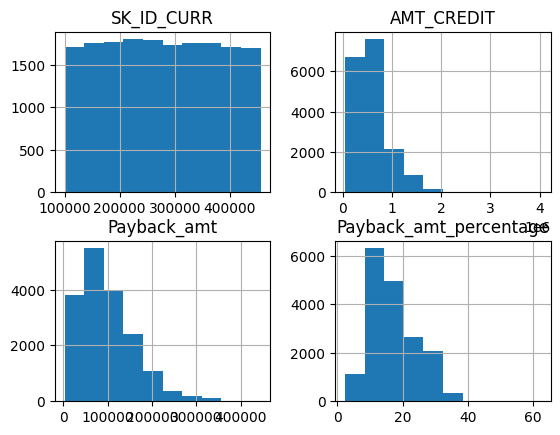

In [ ]:
defaulters_1.hist()

In [ ]:
#customers with target as 0
src_target_0= src[src.TARGET == 0]
#amount to be paid back
payback_amt_0= src_target_0.AMT_CREDIT- src_target_0.AMT_GOODS_PRICE
payback_amt_0
src_target_0['Payback_amt']= payback_amt_0
src_target_perct= src_target_0[['SK_ID_CURR','AMT_CREDIT','Payback_amt']]
src_target_perct['Payback_amt_percentage']= (src_target_perct.Payback_amt/src_target_perct.AMT_CREDIT)*100
src_target_perct

/tmp/ipykernel_35883/841107336.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  src_target_0['Payback_amt']= payback_amt_0
/tmp/ipykernel_35883/841107336.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  src_target_perct['Payback_amt_percentage']= (src_target_perct.Payback_amt/src_target_perct.AMT_CREDIT)*100


,SK_ID_CURR,AMT_CREDIT,Payback_amt,Payback_amt_percentage
1,100003,1293502.5,164002.5,12.678947
2,100004,135000.0,0.0,0.000000
3,100006,312682.5,15682.5,5.015471
4,100007,513000.0,0.0,0.000000
5,100008,490495.5,35995.5,7.338599
...,...,...,...,...
307505,456249,225000.0,0.0,0.000000
307506,456251,254700.0,29700.0,11.660777
307507,456252,269550.0,44550.0,16.527546
307508,456253,677664.0,92664.0,13.674033


In [ ]:
defaulters_0= src_target_perct[src_target_perct.Payback_amt_percentage > 0]
defaulters_0.count()

,0
SK_ID_CURR,181277
AMT_CREDIT,181277
Payback_amt,181277
Payback_amt_percentage,181277


array([[<Axes: title={'center': 'SK_ID_CURR'}>,
        <Axes: title={'center': 'AMT_CREDIT'}>],
       [<Axes: title={'center': 'Payback_amt'}>,
        <Axes: title={'center': 'Payback_amt_percentage'}>]], dtype=object)

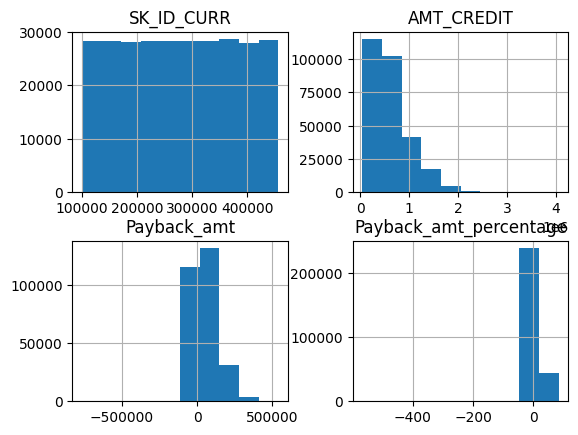

In [ ]:
src_target_perct.hist()

4. Balance the dataset if the data is imbalanced
5. Plot the balanced or imbalanced data
6. Encode the columns that are required for the model

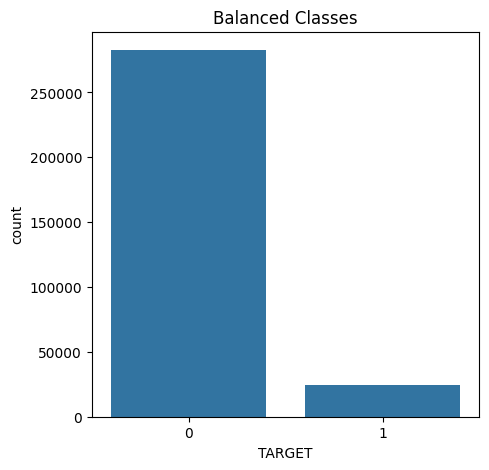

In [ ]:
# Shuffle the Dataset.
shuffled_df= src.sample(frac=1,random_state=4)
# Put all the fraud class in a separate dataset.
fraud_df= shuffled_df.loc[shuffled_df['TARGET']== 1]
#Randomly select 492 observations from the non-fraud (majority class)
non_fraud_df= shuffled_df.loc[shuffled_df['TARGET']== 0]
# Concatenate both dataframes again
normalized_df= pd.concat([fraud_df, non_fraud_df])
#plot the dataset after the undersampling
plt.figure(figsize=(5, 5))
#sns.countplot(normalized_df,'TARGET')
sns.countplot(x='TARGET', data=normalized_df)
plt.title('Balanced Classes')
plt.show()

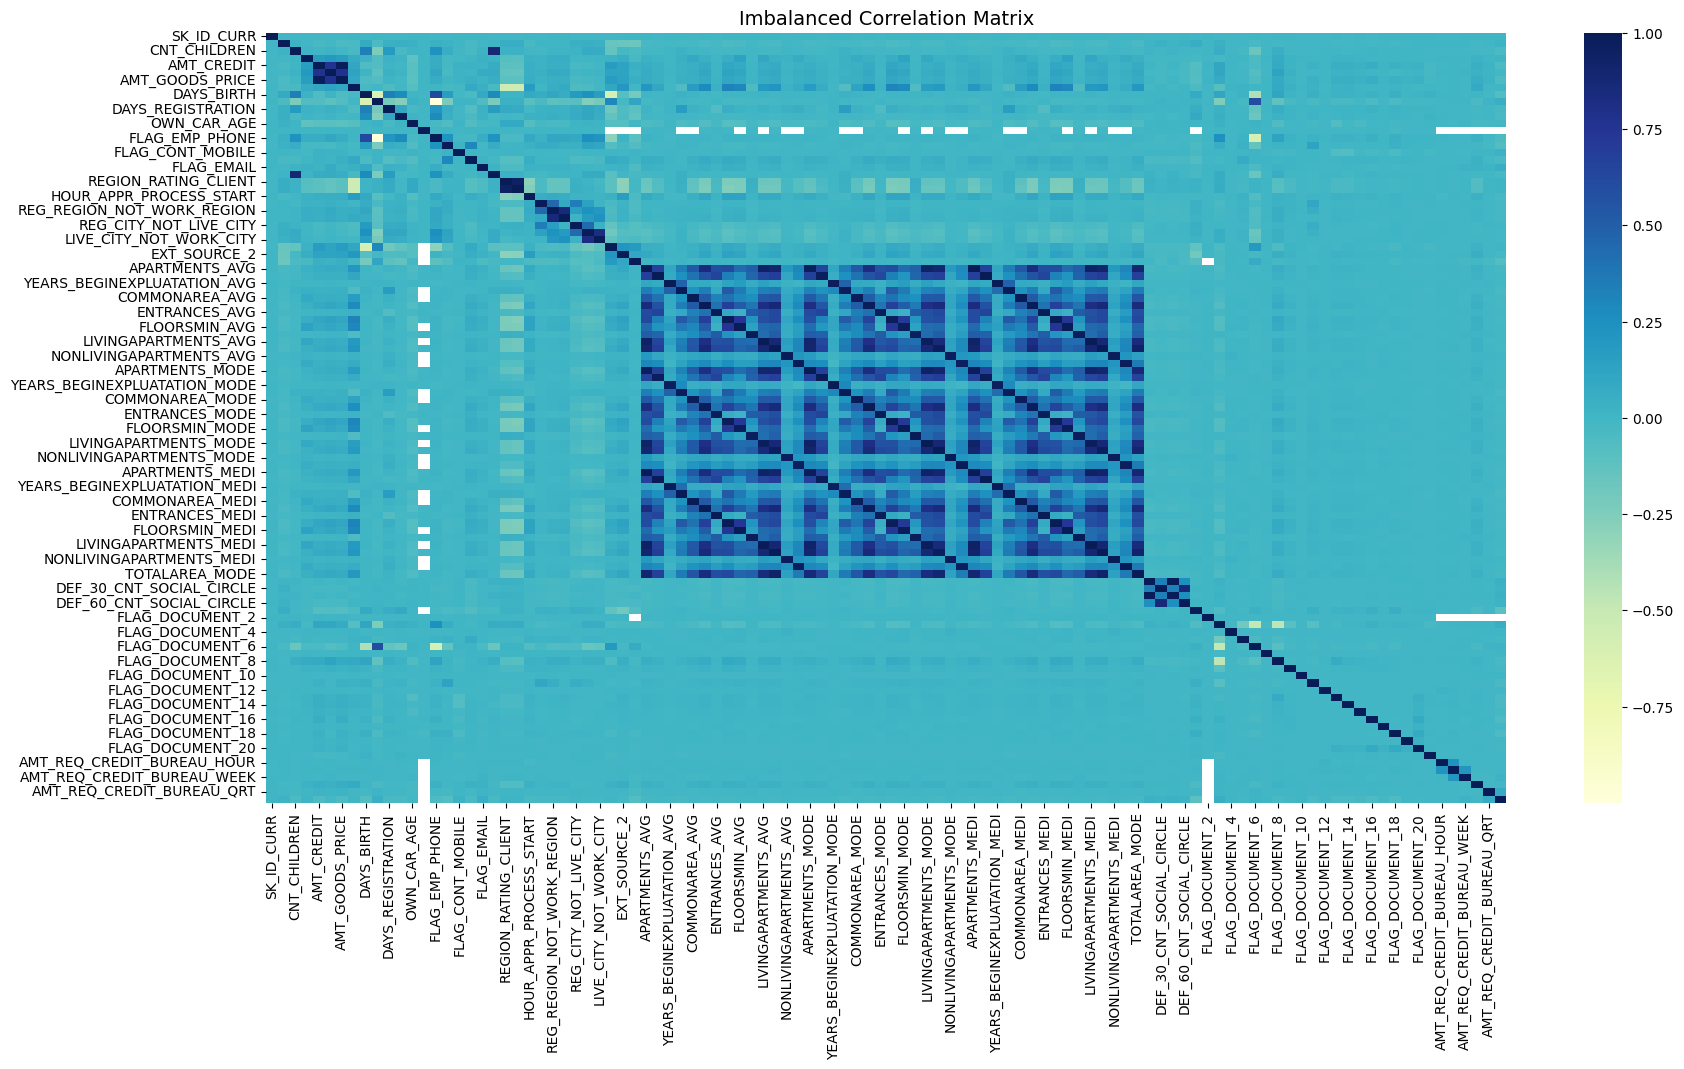

In [ ]:
# Sample figsize in inches
fig, ax = plt.subplots(figsize=(20,10))
# Imbalanced DataFrame Correlation
corr = shuffled_df.corr(numeric_only=True)
sns.heatmap(corr, cmap='YlGnBu', annot_kws={'size':30}, ax=ax)
ax.set_title("Imbalanced Correlation Matrix", fontsize=14)
plt.show()

7. Calculate sensitivity as a metric

In [ ]:
import sklearn as sk
import scipy as sp

In [ ]:
src.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
src.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [ ]:
#Building and training a Logistic Regression model
import statsmodels.formula.api as sm

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

logistic1 = smf.logit(
    formula='TARGET ~ AMT_REQ_CREDIT_BUREAU_HOUR + AMT_REQ_CREDIT_BUREAU_DAY + \
                     AMT_REQ_CREDIT_BUREAU_WEEK + AMT_REQ_CREDIT_BUREAU_MON + \
                     AMT_REQ_CREDIT_BUREAU_QRT + AMT_REQ_CREDIT_BUREAU_YEAR',
    data=shuffled_df
)

fitted1 = logistic1.fit()
fitted1.summary()


Optimization terminated successfully.
         Current function value: 0.271570
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 TARGET   No. Observations:               265992
Model:                          Logit   Df Residuals:                   265985
Method:                           MLE   Df Model:                            6
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                0.001076
Time:                        01:22:25   Log-Likelihood:                -72235.
converged:                       True   LL-Null:                       -72313.
Covariance Type:            nonrobust   LLR p-value:                 5.041e-31
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -2.5364      0.011   -229.474      0.000      -2.558      -2.515
AMT_REQ_CREDIT_BUREAU_HOUR     0.0174      0.087      0.200      0.842      -0.153       0.188
AMT_REQ_CREDIT_BUREAU_DAY      0.0825      0.063      1.306      0.192      -0.041       0.206
AMT_REQ_CREDIT_BUREAU_WEEK    -0.0084      0.036     -0.232      0.817      -0.079       0.063
AMT_REQ_CREDIT_BUREAU_MON     -0.0605      0.009     -6.395      0.000      -0.079      -0.042
AMT_REQ_CREDIT_BUREAU_QRT     -0.0267      0.012     -2.212      0.027      -0.050      -0.003
AMT_REQ_CREDIT_BUREAU_YEAR     0.0392      0.004     10.425      0.000       0.032       0.047
==============================================================================================
"""

In [ ]:
predictors = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

predicted_values1 = fitted1.predict(src[predictors])
predicted_values1[1:10]


,0
1,0.073348
2,0.073348
3,NaN
4,0.073348
5,0.074208
6,0.072761
7,0.073348
8,0.076060
9,NaN


In [ ]:
### Converting predicted values into classes using threshold
threshold=0.5
predicted_class1=np.zeros(predicted_values1.shape)
predicted_class1[predicted_values1>threshold]=1
predicted_class1

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
#Confusion matrix, Accuracy, sensitivity and specificity
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(src[['TARGET']],predicted_class1)
print('Confusion Matrix : \n'
, cm1)
total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)
sensitivity1= cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )
specificity1= cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

Confusion Matrix : 
 [[282686      0]
 [ 24825      0]]
Accuracy :  0.9192711805431351
Sensitivity :  1.0
Specificity :  0.0


In [ ]:
# Converting predicted values into classes using new threshold
threshold=0.8
predicted_class1=np.zeros(predicted_values1.shape)
predicted_class1[predicted_values1>threshold]=1
predicted_class1

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
#Confusion matrix, Accuracy, sensitivity and specificity
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(src[['TARGET']],predicted_class1)
print('Confusion Matrix : \n'
, cm1)
total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

Confusion Matrix : 
 [[282686      0]
 [ 24825      0]]
Accuracy :  0.9192711805431351
